# Hybrid Theil-Sen + Year-on-Year degradation (PVDAQ system 4)

This notebook applies the two-piece hybrid degradation analysis
(`rdtools.degradation_hybrid`) to PVDAQ system 4 -- the same dataset used
in [`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb).

The hybrid method splits the normalized-energy time series at a
configurable boundary (default: 1 year) and fits:

- **Theil-Sen** on the year-1 window, producing a rate in %/year of the
  year-0 system capacity from a robust, non-parametric
  median-of-pairwise-slopes regression.
- **Year-on-year** on the remainder, producing a steady-state rate in
  %/year of the start-of-year-2 capacity (when `recenter_year2=True`).

This is useful when the first year of operation degrades qualitatively
differently from steady state (light-induced degradation, light-soaking,
initial stabilization). A single-rate fit averages those regimes and
hides the nonlinearity. Theil-Sen is preferred over OLS for the year-1
piece because the early-life window is short and a handful of bad days
can dominate an OLS slope.

For full data preparation and the broader `TrendAnalysis` workflow, see
[`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb). This
notebook focuses on the hybrid-specific configuration and outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pvlib
import rdtools
%matplotlib inline


In [2]:
# Update the style of plots
import matplotlib
matplotlib.rcParams.update({'font.size': 12,
                            'figure.figsize': [4.5, 3],
                            'lines.markeredgewidth': 0,
                            'lines.markersize': 2})
# Register time series plotting in pandas > 1.0
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [3]:
# Set the random seed for numpy so the bootstrap-based YoY confidence
# intervals are reproducible across runs.
np.random.seed(0)


## 1. Import and prepare data

Loads PVDAQ system 4 from the cached CSV and assembles the metadata dict
needed by `TrendAnalysis`. The data preparation here mirrors
`TrendAnalysis_example.ipynb`, minus the synthetic soiling multiplication
(we run the hybrid fit on the AC power directly so the result isn't
distorted by the synthetic signal).


In [4]:
# Import the example data
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)


In [5]:
df = df.rename(columns={
    'ac_power': 'power_ac',
    'wind_speed': 'wind_speed',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

# Specify the Metadata
meta = {"latitude": 39.7406,
        "longitude": -105.1774,
        "timezone": 'Etc/GMT+7',
        "gamma_pdc": -0.0034,  # 1/K, modern silicon PV modules
        "azimuth": 180,
        "tilt": 40,
        "power_dc_rated": 1000.0,
        "temp_model_params": 'open_rack_glass_polymer'}

df.index = df.index.tz_localize(meta['timezone'])

# Some missing data, so infer the frequency from the first few points.
freq = pd.infer_freq(df.index[:10])


## 2. Configure `TrendAnalysis`

Same setup as `TrendAnalysis_example.ipynb`. We pass `power_ac` directly
(no synthetic soiling) so the degradation signal is as clean as the
dataset allows.


In [6]:
ta = rdtools.TrendAnalysis(df['power_ac'], df['poa'],
                           temperature_ambient=df['Tamb'],
                           gamma_pdc=meta['gamma_pdc'],
                           interp_freq=freq,
                           windspeed=df['wind_speed'],
                           power_dc_rated=meta['power_dc_rated'],
                           temperature_model=meta['temp_model_params'])


## 3. Run the hybrid analysis

We run year-on-year and hybrid in a single call so we can compare them on
the same preprocessing and filtering pipeline. The analyses are
independent and both results land under `ta.results['sensor']`.


In [7]:
ta.sensor_analysis(
    analyses=['yoy_degradation', 'hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'theil_sen'},
)


The hybrid result is a dict with explicit per-piece rates plus the full
`(Rd_pct, Rd_CI, calc_info)` tuples from each underlying call -- Theil-Sen
for year 1, YoY for years 2+ -- under `calc_info['year1']` and
`calc_info['years2plus']`.


In [8]:
yoy_results    = ta.results['sensor']['yoy_degradation']
hybrid_results = ta.results['sensor']['hybrid_degradation']

print('YoY whole-series:')
print(f"  Rd     = {yoy_results['p50_rd']:+.3f} %/yr   "
      f"68% CI = [{yoy_results['rd_confidence_interval'][0]:+.3f}, "
      f"{yoy_results['rd_confidence_interval'][1]:+.3f}]")

print('\nHybrid (year 1 Theil-Sen + years 2+ YoY):')
ci1 = hybrid_results['calc_info']['year1'][1]
ci2 = hybrid_results['calc_info']['years2plus'][1]
print(f"  year 1   Rd = {hybrid_results['rd_pct_year1']:+.3f} %/yr   "
      f"68% CI = [{ci1[0]:+.3f}, {ci1[1]:+.3f}]")
print(f"  years 2+ Rd = {hybrid_results['rd_pct_years2plus']:+.3f} %/yr   "
      f"68% CI = [{ci2[0]:+.3f}, {ci2[1]:+.3f}]")
print(f"  split at:     {hybrid_results['calc_info']['split_date']:%Y-%m-%d}")


YoY whole-series:
  Rd     = -0.456 %/yr   68% CI = [-0.531, -0.418]

Hybrid (year 1 Theil-Sen + years 2+ YoY):
  year 1   Rd = +0.351 %/yr   68% CI = [-0.045, +0.711]
  years 2+ Rd = -0.422 %/yr   68% CI = [-0.473, -0.378]
  split at:     2011-02-25


## 4. Plot the hybrid summary

`TrendAnalysis.plot_hybrid_degradation_summary` returns a two-panel
figure:

- **Left:** scatter of the daily aggregated normalized performance with
  the year-1 OLS fit line, the years-2+ YoY rate line, and a vertical
  marker at the split date.
- **Right:** histogram of the years-2+ YoY slopes, the dashed line at
  the median rate, and a text annotation with both rates and their 68%
  confidence intervals.


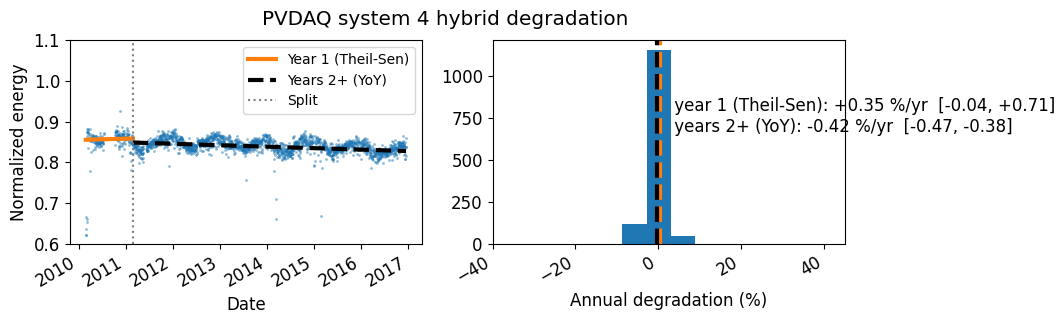

In [9]:
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid degradation',
    scatter_ymin=0.6, scatter_ymax=1.1,
    hist_xmin=-40, hist_xmax=45,
)
plt.show()


## 5. Configuration knobs

The hybrid analysis exposes a few parameters via `hybrid_kwargs`:

- `year1_split` (default `1.0`): boundary in years between the year-1 and
  year-on-year windows. Set higher (e.g. `1.5` or `2.0`) if the early-life
  regime is wider than a year. Values below ~1 leave too little data for
  OLS to separate trend from seasonality.
- `year1_method` (default `'ols'`): which regression to run on the
  year-1 window. Built-in choices are `'ols'`
  ([`degradation_ols`](../api.html#rdtools.degradation_ols)) and
  `'classical_decomposition'`
  ([`degradation_classical_decomposition`](../api.html#rdtools.degradation_classical_decomposition));
  any callable with the same return contract is also accepted, so future
  regression methods can be plugged in without changes here.
- `year1_kwargs`: forwarded to the year-1 method (parallel to
  `yoy_kwargs`).
- `recenter_year2` (default `True`): when `True`, the years-2+ rate is
  reported relative to the start-of-year-2 capacity. When `False`, the
  rate keeps the year-0 baseline of the input.
- `yoy_kwargs`: forwarded to `degradation_year_on_year` (e.g.
  `uncertainty_method='circular_block'`, `multi_yoy=True`).

The two cells below illustrate (a) a wider year-1 window and (b)
swapping the year-1 method to classical decomposition. Because
preprocessing was already done on the first `sensor_analysis` call,
only the degradation step is recomputed.


In [10]:
# Re-run hybrid only with a wider year-1 window.
ta.sensor_analysis(analyses=['hybrid_degradation'],
                   hybrid_kwargs={'year1_split': 1.5})

hybrid_alt = ta.results['sensor']['hybrid_degradation']
print(f"year1_split = 1.5")
print(f"  first-1.5-yr Rd = {hybrid_alt['rd_pct_year1']:+.3f} %/yr")
print(f"  years 2+ Rd     = {hybrid_alt['rd_pct_years2plus']:+.3f} %/yr")
print(f"  split at:         {hybrid_alt['calc_info']['split_date']:%Y-%m-%d}")


year1_split = 1.5
  first-1.5-yr Rd = +0.270 %/yr
  years 2+ Rd     = -0.558 %/yr
  split at:         2011-08-26


In [11]:
# Swap the year-1 method to classical decomposition.  CD uses a
# centered 365-day rolling mean and trims the first/last 0.5 years of
# its window, so it needs at least ~1.5 years of year-1 data -- we use
# year1_split = 2.0 to give it a comfortable window.
#
# CD also requires a *regular* (fixed-freq, gap-free) series, while the
# aggregated, filtered output produced by `TrendAnalysis` contains NaN
# gaps from the filter step.  We wrap CD in a small adapter that
# interpolates the year-1 slice first -- this also demonstrates passing
# an arbitrary callable through `year1_method`.
def cd_interpolated(series, confidence_level=68.2):
    return rdtools.degradation_classical_decomposition(
        series.interpolate(method='time'),
        confidence_level=confidence_level,
    )

ta.sensor_analysis(analyses=['hybrid_degradation'],
                   hybrid_kwargs={'year1_split': 2.0,
                                  'year1_method': cd_interpolated})

hybrid_cd = ta.results['sensor']['hybrid_degradation']
print(f"year1_method = cd_interpolated, year1_split = 2.0")
print(f"  first-2-yr Rd = {hybrid_cd['rd_pct_year1']:+.3f} %/yr")
print(f"  years 3+ Rd   = {hybrid_cd['rd_pct_years2plus']:+.3f} %/yr")
print(f"  split at:       {hybrid_cd['calc_info']['split_date']:%Y-%m-%d}")
print(f"  MK trend test:  {hybrid_cd['calc_info']['year1'][2]['mk_test_trend']}")


year1_method = cd_interpolated, year1_split = 2.0
  first-2-yr Rd = -1.069 %/yr
  years 3+ Rd   = -0.566 %/yr
  split at:       2012-02-25
  MK trend test:  decreasing


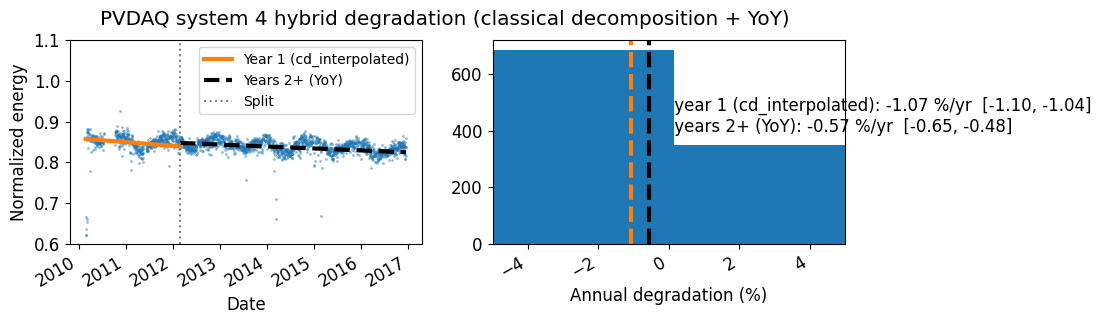

In [12]:
# The plot method reads whichever hybrid result is currently stored
# under ta.results['sensor']['hybrid_degradation'], so the figure below
# reflects the classical-decomposition run from the cell above.
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid degradation (classical decomposition + YoY)',
    scatter_ymin=0.6, scatter_ymax=1.1,
    hist_xmin=-5, hist_xmax=5,
)
plt.show()
